# Optimized token demand across industry regimes

This notebook studies how token demand responds to token price $c$, token efficiency $\eta$, and model capability $m$. Every point re-solves the user's choices:

- delegation horizon $s$ (human-hours of work between checkpoints),
- inference intensity $x$ (tokens per work-hour, per attempt), and
- retry cap $k$.

The user maximizes expected surplus—not token consumption. All demand and spending figures use the abundant-work, attention-limited regime with 100,000 human verification hours available per industry and period. The level is a normalization; changing it scales demand without changing the curves. The calibrations are illustrative and should not be read as estimates.

## Setup

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from modeling_token_demand import (
    IndustryModel,
    OptimizationSettings,
    PolicyOptimizer,
    Scenario,
    illustrative_industries,
)

FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)
ATTENTION_HOURS_PER_INDUSTRY = 100_000.0
industries = tuple(
    replace(industry, human_attention_hours=ATTENTION_HOURS_PER_INDUSTRY)
    for industry in illustrative_industries(include_threshold=False)
)

## What distinguishes the industries

For a candidate user action $(s,x,k)$—delegation horizon, tokens per work-hour in each attempt, and retry cap—the parameters enter the model through the following chain. First, the capability and execution equations are

$$
q_i(s;m)=\exp\left[-\left(\frac{s}{\lambda_i m}\right)^{\nu_i}\right],
\qquad
r_i(s,x;m,\eta)=\exp\left[-\frac{s}{a_i m[\eta(x/x_{\mathrm{ref}})]^{\alpha_i}}\right].
$$

Here $q_i$ is the share of tasks inside the capability frontier, while $r_i$ is the success probability of one attempt conditional on the task being solvable. The normalization $x_{\mathrm{ref}}$ only keeps the numerical units convenient. With at most $k$ attempts,

$$
P_i=q_i[1-(1-r_i)^k],
\qquad
E_i=(1-q_i)k+q_i\frac{1-(1-r_i)^k}{r_i},
$$

where $P_i$ is eventual success and $E_i$ is expected attempts. Human verification time and expected surplus per work-hour are

$$
h_i(s)=v[h_{0,i}+h_{1,i}s^{\beta_i}],
\qquad
u_i(s,x,k)=b_iP_i-E_i\left(cx+w_i\frac{h_i(s)}{s}\right).
$$

The user chooses $(s_i^\star,x_i^\star,k_i^\star)$ to maximize $u_i$. In the broader model, optimized surplus determines adoption:

$$
A_i=\frac{1}{1+\exp[-(u_i^\star-\mu_i)/\sigma_i]},
$$

$$
D_i^{\mathrm{work}}=W_iA_ix_i^\star E_i^\star,
\qquad
D_i^{\mathrm{attention}}=H_i\frac{s_i^\star x_i^\star}{h_i(s_i^\star)}.
$$

This notebook assumes useful work is abundant and human attention is the binding resource, so every demand plot reports $D_i=D_i^{\mathrm{attention}}$. The expected retry count cancels because each retry consumes both another $sx$ tokens and another checkpoint $h_i(s)$. Adoption parameters and potential work volume therefore do not move these attention-limited curves.

This makes the role of each industry parameter reasonably direct:

- $\lambda_i$ and $\nu_i$ shape the capability frontier $q_i$. A larger $\lambda_i$ supports longer tasks; $\nu_i$ controls how sharply feasibility falls near the frontier.
- $a_i$ and $\alpha_i$ shape conditional execution reliability $r_i$. A larger $a_i$ makes execution easier; $\alpha_i$ controls the diminishing return to additional inference.
- $h_{0,i}$, $h_{1,i}$, and $\beta_i$ determine human verification time. A $\beta_i$ near one means review grows almost proportionally with delegated scope.
- $b_i$ values successful work, while $w_i$ prices the human attention spent verifying it. Both directly affect the action the user finds worthwhile.
- $H_i$ is available human verification time and scales attention-limited demand proportionally.
- $\mu_i$, $\sigma_i$, and $W_i$ govern adoption and available work in the broader model, but they are inactive in the strictly attention-limited figures below.

The scenario variables are common comparative-statics inputs rather than industry characteristics: model capability $m$, token efficiency $\eta$, token price $c$, and the verification-time multiplier $v$.

In [2]:
characteristics = {
    "Software development": (
        "Broad capability frontier with verification that grows slowly with delegated scope."
    ),
    "High-review professional work": (
        "Verification is expensive and nearly linear in delegated scope (high h1 and beta)."
    ),
    "Routine automation": (
        "Easy execution, long feasible tasks, and cheap, strongly sublinear verification."
    ),
    "Capability-limited frontier work": (
        "Short capability horizon and difficult execution, offset by high-value output."
    ),
}

header = (
    "| Industry | lambda | a | alpha | h1 | beta | b | mu | sigma | Key characteristic |\n"
    "|---|---:|---:|---:|---:|---:|---:|---:|---:|---|\n"
)
rows = []
for industry in industries:
    rows.append(
        f"| {industry.name} | {industry.capability_horizon_hours:g} | "
        f"{industry.execution_scale:g} | {industry.inference_returns:g} | "
        f"{industry.verification_scale:g} | "
        f"{industry.verification_elasticity:g} | "
        f"{industry.value_per_work_hour:g} | {industry.adoption_midpoint:g} | "
        f"{industry.adoption_scale:g} | {characteristics[industry.name]} |"
    )
display(Markdown(header + "\n".join(rows)))

| Industry | lambda | a | alpha | h1 | beta | b | mu | sigma | Key characteristic |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---|
| Software development | 15 | 5 | 0.55 | 0.025 | 0.35 | 125 | 112 | 6 | Broad capability frontier with verification that grows slowly with delegated scope. |
| High-review professional work | 12 | 4 | 0.5 | 0.13 | 0.95 | 125 | 100 | 7 | Verification is expensive and nearly linear in delegated scope (high h1 and beta). |
| Routine automation | 40 | 8 | 0.45 | 0.012 | 0.25 | 100 | 30 | 8 | Easy execution, long feasible tasks, and cheap, strongly sublinear verification. |
| Capability-limited frontier work | 2 | 1.5 | 0.6 | 0.08 | 0.5 | 220 | 152 | 10 | Short capability horizon and difficult execution, offset by high-value output. |

## Numerical solution

The optimizer enumerates every integer retry cap and, conditional on each $k$, searches for the best $(s,x)$ in log space using a grid plus bounded multi-start local optimization. The action ranges below are intentionally wider than the ranges used in the original paper table. None of the plotted optima touches a continuous bound or the maximum retry cap.

In [3]:
settings = OptimizationSettings(
    min_delegation_hours=0.02,
    max_delegation_hours=80.0,
    min_tokens_per_work_hour=2_000.0,
    max_tokens_per_work_hour=2_000_000.0,
    max_attempts=12,
    grid_points_per_dimension=15,
    local_starts_per_attempt=3,
)
optimizer = PolicyOptimizer(settings)
baseline = Scenario()

In [4]:
def solve_axis(scenario_field, values):
    """Reoptimize every industry at every value on one scenario axis."""
    results = {}
    for industry in industries:
        model = IndustryModel(industry)
        results[industry.name] = [
            optimizer.solve(
                model, replace(baseline, **{scenario_field: float(value)})
            )
            for value in values
        ]
    return results


MARKERS = ("o", "s", "^", "D", "P")
PRICE_TICKS = (1, 2, 5, 10, 20, 40, 80)
TECHNOLOGY_TICKS = (0.35, 0.5, 1, 2, 3, 5)


def label_log_x_axis(ax, ticks):
    """Show informative numeric labels instead of sparse powers of ten."""
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{tick:g}" for tick in ticks])


def attention_limited_tokens(outcome):
    """Return demand under abundant work and a binding attention constraint."""
    if outcome.attention_limited_tokens is None:
        raise ValueError("human_attention_hours must be set for these plots")
    return outcome.attention_limited_tokens


def plot_demand(
    values, results, xlabel, filename, baseline_value, xticks, reverse_x=False
):
    """Plot every optimized demand point with an industry-specific marker."""
    fig, ax = plt.subplots(figsize=(10, 6.2), constrained_layout=True)
    for index, (industry_name, outcomes) in enumerate(results.items()):
        demand = np.array([attention_limited_tokens(outcome) / 1e9 for outcome in outcomes])
        ax.plot(
            values, demand, label=industry_name, marker=MARKERS[index],
            markersize=4.5, markeredgecolor="white", markeredgewidth=0.5,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    label_log_x_axis(ax, xticks)
    ax.axvline(baseline_value, color="0.35", linestyle="--", linewidth=1.2)
    if reverse_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Attention-limited token demand (billions per period)")
    ax.grid(which="major", alpha=0.25)
    ax.grid(which="minor", alpha=0.10)
    ax.legend(frameon=False, fontsize=9)
    fig.savefig(FIGURE_DIR / filename, dpi=180)
    return fig


def plot_token_spend(values, results, filename, xticks):
    """Plot c times D(c), with spending reported in millions of dollars."""
    fig, ax = plt.subplots(figsize=(10, 6.2), constrained_layout=True)
    for index, (industry_name, outcomes) in enumerate(results.items()):
        spend = np.array([
            attention_limited_tokens(outcome) * price_per_million / 1e12
            for outcome, price_per_million in zip(outcomes, values)
        ])
        ax.plot(
            values, spend, label=industry_name, marker=MARKERS[index],
            markersize=4.5, markeredgecolor="white", markeredgewidth=0.5,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    label_log_x_axis(ax, xticks)
    ax.axvline(10.0, color="0.35", linestyle="--", linewidth=1.2)
    ax.invert_xaxis()
    ax.set_xlabel("Token price, $ per million tokens (lower cost to the right)")
    ax.set_ylabel("Attention-limited token spend ($ millions per period)")
    ax.grid(which="major", alpha=0.25)
    ax.grid(which="minor", alpha=0.10)
    ax.legend(frameon=False, fontsize=9)
    fig.savefig(FIGURE_DIR / filename, dpi=180)
    return fig


def plot_surplus_by_capability(capabilities, results, filename, xticks):
    """Plot optimized surplus as model capability changes."""
    fig, ax = plt.subplots(figsize=(10, 6.2), constrained_layout=True)
    for index, (industry_name, outcomes) in enumerate(results.items()):
        surplus = np.array([outcome.surplus_per_work_hour for outcome in outcomes])
        ax.plot(
            capabilities, surplus, label=industry_name, marker=MARKERS[index],
            markersize=4.5, markeredgecolor="white", markeredgewidth=0.5,
        )

    ax.set_xscale("log")
    label_log_x_axis(ax, xticks)
    ax.axvline(1.0, color="0.35", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Model capability, $m$")
    ax.set_ylabel("Optimized surplus, $u_i^\\star$ (dollars per work-hour)")
    ax.grid(which="major", alpha=0.25)
    ax.grid(which="minor", alpha=0.10)
    ax.legend(frameon=False, fontsize=9)
    fig.savefig(FIGURE_DIR / filename, dpi=180)
    return fig


def print_retry_switches(values, results):
    """Describe the discrete choices behind visible demand kinks."""
    for industry_name, outcomes in results.items():
        retries = np.array([outcome.policy.max_attempts for outcome in outcomes])
        switches = np.flatnonzero(retries[1:] != retries[:-1]) + 1
        if len(switches):
            descriptions = [
                f"{values[j - 1]:.3g} to {values[j]:.3g}: k {retries[j - 1]} to {retries[j]}"
                for j in switches
            ]
            print(f"{industry_name}: " + "; ".join(descriptions))

### Baseline optimized policies

In [5]:
baseline_rows = []
for industry in industries:
    outcome = optimizer.solve(IndustryModel(industry), baseline)
    baseline_rows.append(
        f"| {industry.name} | {outcome.policy.delegation_hours:.3f} | "
        f"{outcome.policy.tokens_per_work_hour:,.0f} | {outcome.policy.max_attempts} | "
        f"{outcome.eventual_success:.1%} | "
        f"{attention_limited_tokens(outcome) / 1e9:.1f} |"
    )
baseline_header = (
    "| Industry | s* (hours) | x* (tokens/hour) | k* | Success | Attention demand (billions) |\n"
    "|---|---:|---:|---:|---:|---:|\n"
)
display(Markdown(baseline_header + "\n".join(baseline_rows)))

| Industry | s* (hours) | x* (tokens/hour) | k* | Success | Attention demand (billions) |
|---|---:|---:|---:|---:|---:|
| Software development | 0.897 | 88,118 | 4 | 97.0% | 133.8 |
| High-review professional work | 0.465 | 115,150 | 3 | 97.5% | 61.0 |
| Routine automation | 1.385 | 33,010 | 6 | 98.9% | 120.3 |
| Capability-limited frontier work | 0.328 | 366,432 | 2 | 91.5% | 140.0 |

## Token price

The horizontal axis is reversed, so moving right means tokens become cheaper. The dashed line is the baseline price. Every optimized scenario is shown with an industry-specific marker, and the lines connect those solved points.

Software development: 3.93 to 4.51: k 3 to 4; 26.7 to 30.7: k 4 to 5
High-review professional work: 2.99 to 3.43: k 2 to 3
Routine automation: 3.43 to 3.93: k 5 to 6; 13.5 to 15.5: k 6 to 7; 40.3 to 46.3: k 7 to 8
Capability-limited frontier work: 46.3 to 53: k 2 to 3


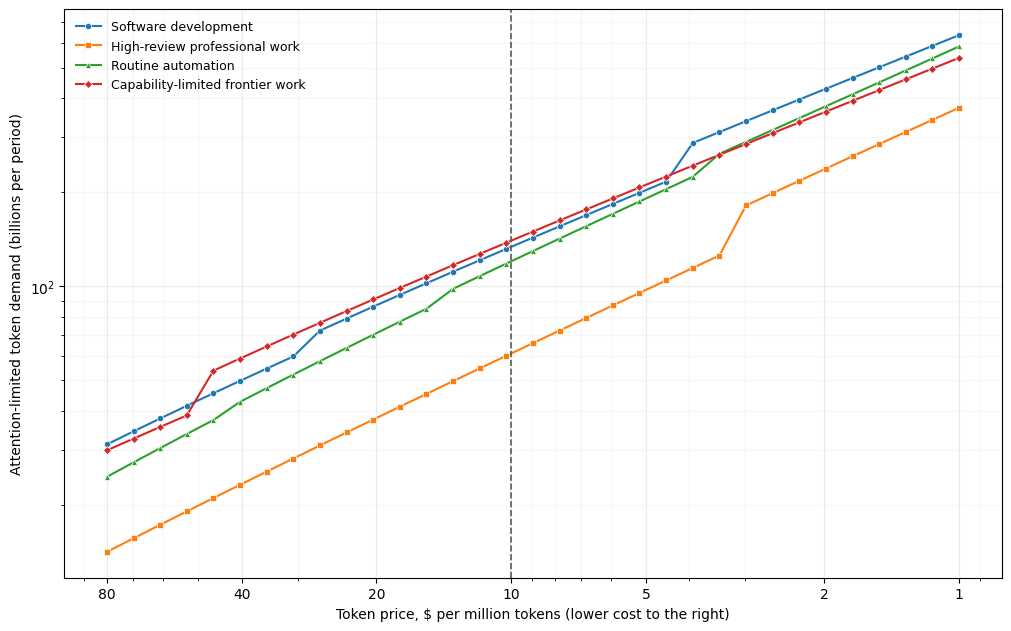

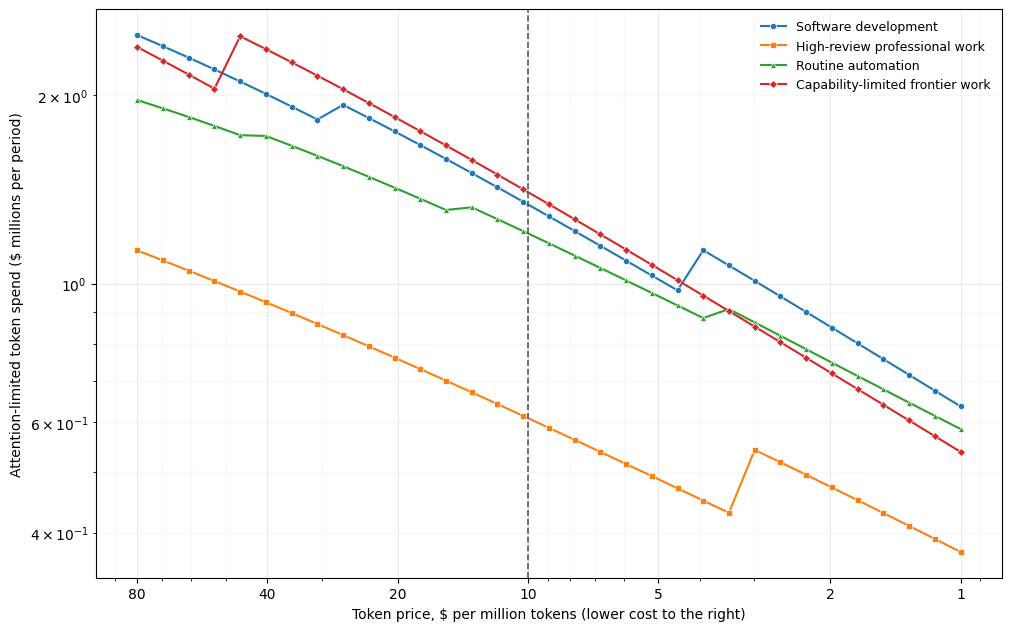

In [6]:
token_prices = np.geomspace(1.0, 80.0, 33)
price_results = solve_axis("token_price_per_million", token_prices)
print_retry_switches(token_prices, price_results)
price_figure = plot_demand(
    token_prices,
    price_results,
    xlabel="Token price, $ per million tokens (lower cost to the right)",
    filename="token-demand-vs-price.png",
    baseline_value=10.0,
    xticks=PRICE_TICKS,
    reverse_x=True,
)
spend_figure = plot_token_spend(
    token_prices, price_results, filename="token-spend-vs-price.png",
    xticks=PRICE_TICKS,
)

Cheaper tokens can increase attention-limited demand because users choose greater inference intensity for each unit of work launched by a scarce human checkpoint. That is a quantity response to price, but an exogenous price cut producing more demand is not by itself Jevons paradox. The stricter Jevons-style experiment is the efficiency plot below: it asks whether using each token more effectively causes total token use to rise.

The second price figure reports token spend $cD(c)$. Moving right while a spending curve rises would mean token demand increased more than proportionally to the price decline, so the absolute price elasticity of demand exceeded one. In these calibrations, spending generally falls as tokens become cheaper: attention-limited token quantity rises, but not enough to offset the lower price.

## Token efficiency

Higher $\eta$ means each token buys more effective inference while model capability $m$ is held fixed. Thus this experiment isolates efficiency from an outward shift in the capability frontier.

Software development: 0.35 to 0.38: k 5 to 4; 2.37 to 2.57: k 4 to 3
High-review professional work: 2.79 to 3.04: k 3 to 2
Routine automation: 0.68 to 0.739: k 7 to 6; 2.37 to 2.57: k 6 to 5


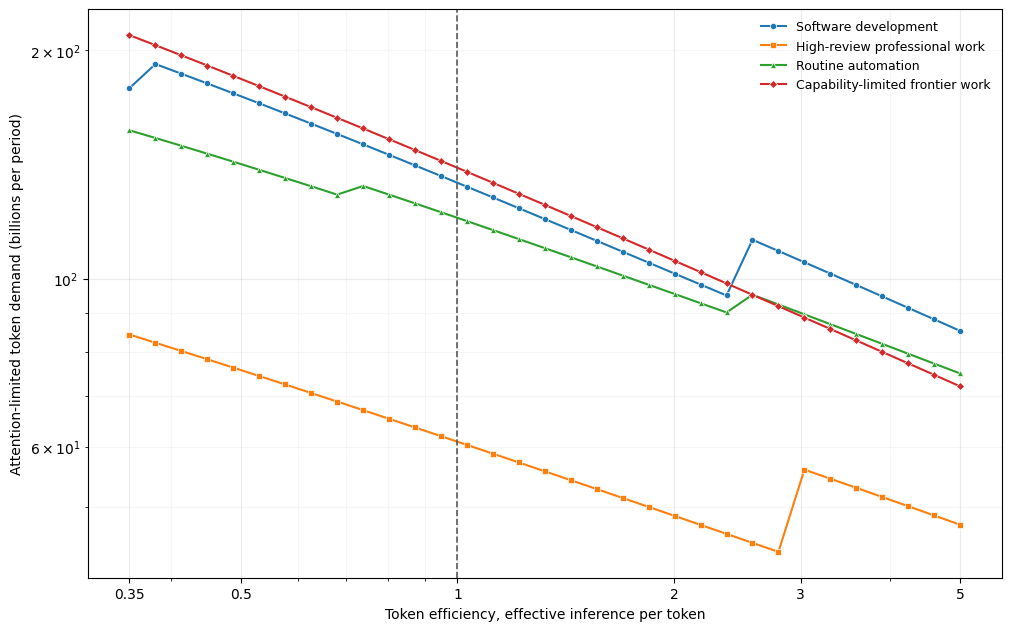

In [7]:
token_efficiencies = np.geomspace(0.35, 5.0, 33)
efficiency_results = solve_axis("token_efficiency", token_efficiencies)
print_retry_switches(token_efficiencies, efficiency_results)
efficiency_figure = plot_demand(
    token_efficiencies,
    efficiency_results,
    xlabel="Token efficiency, effective inference per token",
    filename="token-demand-vs-efficiency.png",
    baseline_value=1.0,
    xticks=TECHNOLOGY_TICKS,
)

In the attention-limited regime, efficiency affects demand through two opposing choices. It lowers the tokens needed for a given inference effort, but it may let each scarce human checkpoint launch a larger delegated chunk. Jevons-style growth occurs only if the increase in supervisory leverage $s_i^\star/h_i(s_i^\star)$ outweighs the decline in chosen token intensity $x_i^\star$.

Across these four illustrative calibrations, attention-limited demand generally falls as $\eta$ rises. The increase in supervisory leverage is not large enough to offset lower chosen token intensity, so this calibration does **not** recover Jevons paradox from inference efficiency alone. An attention-driven Jevons case would require a stronger expansion of $s_i^\star/h_i(s_i^\star)$, for example in a regime where verification scales especially slowly and capability improvements induce much longer delegation. Increasing model capability $m$ is a different experiment because it also moves the solvable-task frontier $q_i$.

## Model capability

Model capability directly expands the share of tasks inside the capability frontier:

$$
q_i(s;m)=\exp\left[-\left(\frac{s}{\lambda_i m}\right)^{\nu_i}\right],
\qquad
\frac{\partial q_i}{\partial m}
=\frac{q_i\nu_i}{m}\left(\frac{s}{\lambda_i m}\right)^{\nu_i}>0.
$$

Holding the task horizon $s$ fixed, $q_i$ therefore rises monotonically toward one as $m$ increases. The effect is largest when an industry is near its capability frontier; once $q_i$ is already near one, this direct channel becomes small.

The plotted response is broader than this derivative. In the model, larger $m$ also raises conditional execution reliability $r_i$, and the user reoptimizes $s$, $x$, and $k$. Attention-limited demand is then recalculated as $H_i s_i^\star x_i^\star/h_i(s_i^\star)$. A line rises when capability expands work launched per checkpoint faster than chosen token intensity falls, and declines when the inference-efficiency effect dominates.

Software development: 0.449 to 0.488: k 3 to 4; 3.04 to 3.3: k 4 to 5
Routine automation: 1.56 to 1.7: k 6 to 7
Capability-limited frontier work: 2.37 to 2.57: k 2 to 3


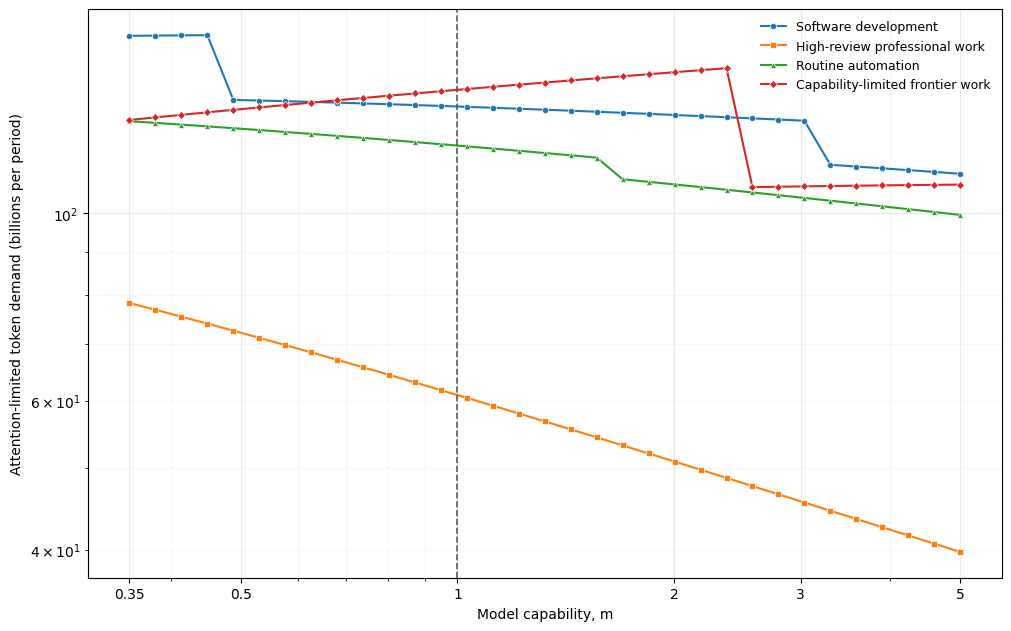

In [8]:
model_capabilities = np.geomspace(0.35, 5.0, 33)
capability_results = solve_axis("model_capability", model_capabilities)
print_retry_switches(model_capabilities, capability_results)
capability_figure = plot_demand(
    model_capabilities,
    capability_results,
    xlabel="Model capability, m",
    filename="token-demand-vs-capability.png",
    baseline_value=1.0,
    xticks=TECHNOLOGY_TICKS,
)

Unlike a pure efficiency improvement, a capability improvement shifts both $q_i$ and $r_i$. Users respond by changing delegation length and inference intensity. In this strictly attention-limited accounting, newly feasible work does not multiply demand through adoption; it matters only through the optimized interaction policy and the amount of machine work each human checkpoint can supervise.

The decomposition explains why most curves still slope downward. For software, raising $m$ from 1 to 5 increases supervisory leverage $s_i^\star/h_i(s_i^\star)$ from 15.2 to 34.5, but chosen intensity falls from 88,100 to 32,300 tokens per work-hour; their product, tokens per scarce human hour, falls from 1.34 million to 1.11 million. High-review work gains much less leverage because $\beta_i$ is near one. Frontier work initially rises as capability unlocks longer delegation, then falls after lower inference intensity takes over.

### Optimized surplus as capability improves

The next figure plots model capability $m$ on the horizontal axis and optimized user surplus $u_i^\star$ on the vertical axis. It shows how much additional economic value users can extract as model capability improves in each industry.

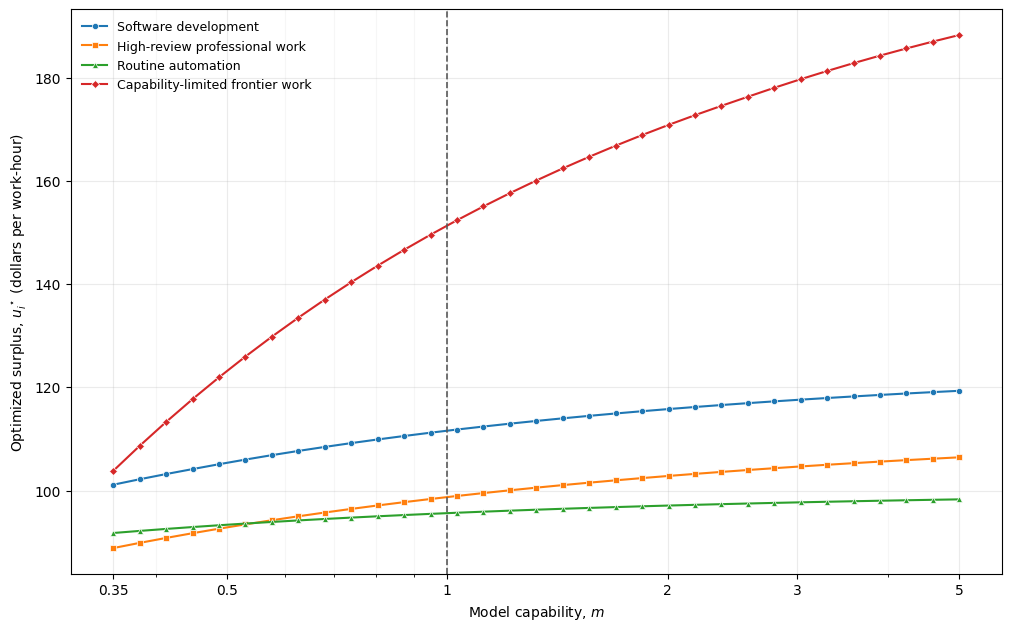

In [9]:
surplus_capability_figure = plot_surplus_by_capability(
    model_capabilities,
    capability_results,
    filename="optimized-surplus-vs-model-capability.png",
    xticks=TECHNOLOGY_TICKS,
)

The adoption-threshold calibration is intentionally excluded from this attention-limited notebook because it differs from software development only through $\mu_i$ and $\sigma_i$, which do not enter attention-limited demand or the user's optimized surplus. It will be useful later when comparing work-limited industries. The dashed vertical line marks baseline capability $m=1$.

## Why some curves have kinks

For a fixed retry cap, the optimized surplus surface is smooth. The overall policy need not be smooth because $k$ is an integer. A kink or small jump in token demand can occur when the surplus-maximizing policy switches from one retry cap to another; token demand itself is not the user's objective and can jump even when the maximized surplus is nearly continuous.

The cell below shows the leading fixed-$k$ policies on opposite sides of one efficiency-driven switch.

In [10]:
software_model = IndustryModel(industries[0])
comparison_rows = []
for eta in (2.5, 2.8):
    by_attempts = optimizer.solve_by_attempts(
        software_model, replace(baseline, token_efficiency=eta)
    )
    ranked = sorted(
        by_attempts.values(), key=lambda item: item.surplus_per_work_hour, reverse=True
    )[:3]
    for rank, outcome in enumerate(ranked, start=1):
        comparison_rows.append(
            f"| {eta:g} | {rank} | {outcome.policy.max_attempts} | "
            f"{outcome.policy.delegation_hours:.3f} | "
            f"{outcome.policy.tokens_per_work_hour:,.0f} | "
            f"{outcome.surplus_per_work_hour:.6f} | "
            f"{attention_limited_tokens(outcome) / 1e9:.2f} |"
        )
comparison_header = (
    "| eta | Rank | k | s* | x* | Surplus/hour | Demand (billions) |\n"
    "|---:|---:|---:|---:|---:|---:|---:|\n"
)
display(Markdown(comparison_header + "\n".join(comparison_rows)))

| eta | Rank | k | s* | x* | Surplus/hour | Demand (billions) |
|---:|---:|---:|---:|---:|---:|---:|
| 2.5 | 1 | 4 | 0.935 | 59,087 | 112.441795 | 92.95 |
| 2.5 | 2 | 3 | 0.909 | 74,119 | 112.440561 | 113.83 |
| 2.5 | 3 | 5 | 0.937 | 54,331 | 112.270156 | 85.66 |
| 2.8 | 1 | 3 | 0.914 | 70,413 | 112.537972 | 108.67 |
| 2.8 | 2 | 4 | 0.938 | 56,298 | 112.523302 | 88.83 |
| 2.8 | 3 | 5 | 0.939 | 51,956 | 112.347613 | 82.09 |

### Optimizer audit

As a separate validation, the retry-switch neighborhoods and representative interior points from the price and efficiency sweeps were compared against SciPy's independent differential-evolution global optimizer. Across 42 industry/scenario cases, the largest surplus difference was $2.1\times10^{-12}$ dollars per work-hour and the selected retry cap agreed in every case. A wider search allowing up to 20 retries selected at most eight. In the four-industry capability sweep, none of the 132 optimized policies touches a continuous search bound and the largest selected retry cap is seven out of the 12 allowed. This does not constitute a formal proof of global optimality, but it is strong numerical evidence that the visible shapes are not failed local searches.

All demand and spending plots assume abundant useful work and 100,000 available human verification hours per industry. They use the model's attention-limited polar case while retaining the per-work-hour surplus policy objective. A full attention-market equilibrium—in which users reoptimize against the shadow price of scarce attention—remains a separate extension.